<a href="https://colab.research.google.com/github/challasreeja87-afk/Machine-Learning/blob/main/MLexp4student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score)

In [17]:
#load the dataset
df = pd.read_csv("placement_predict_50k Dataset.csv")
print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

First 5 rows:
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2             49.4          

In [18]:
print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  object 
 2   City                50000 non-null  object 
 3   CollegeTier         50000 non-null  object 
 4   Stream              50000 non-null  object 
 5   Specialisation      50000 non-null  object 
 6   Hostel              50000 non-null  object 
 7   HistoryOfBacklogs   50000 non-null  object 
 8   SGPA_Sem1           50000 non-null  float64
 9   SGPA_Sem2           50000 non-null  float64
 10  SGPA_Sem3           50000 non-null  float64
 11  SGPA_Sem4           50000 non-null  float64
 12  SGPA_Sem5           50000 non-null  float64
 13  SGPA_Sem6           50000 non-null  float64
 14  SGPA_Sem7           50000 non-null  float64
 15  SGPA_Sem8           50000 non-n

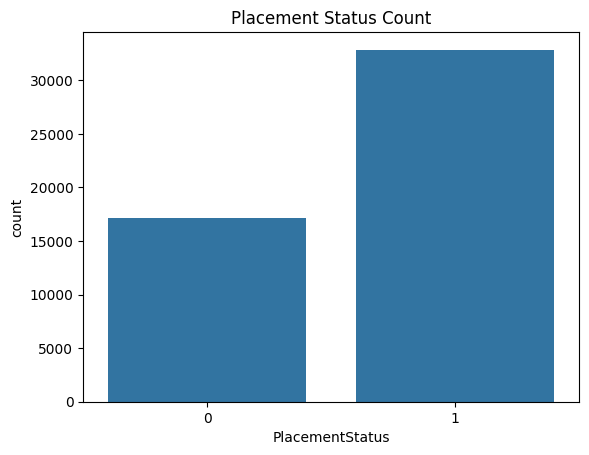

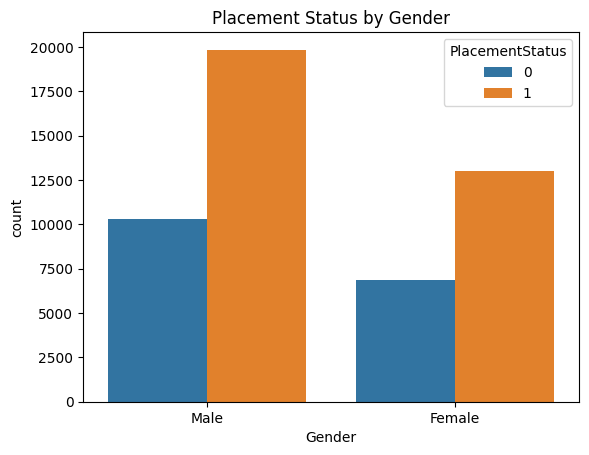

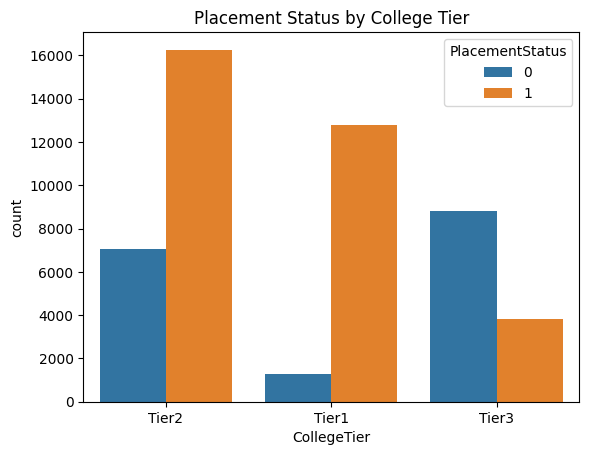

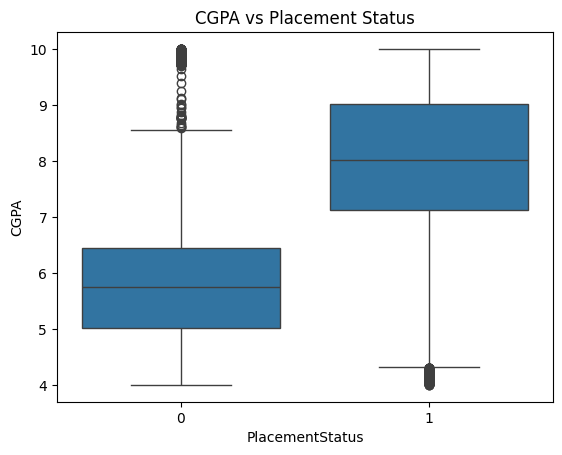

In [19]:
# Placement Status Count

sns.countplot(x="PlacementStatus", data=df)
plt.title("Placement Status Count")
plt.show()


# Placement based on Gender

sns.countplot(
    x="Gender",
    hue="PlacementStatus",
    data=df
)

plt.title("Placement Status by Gender")
plt.show()


# Placement based on College Tier

sns.countplot(
    x="CollegeTier",
    hue="PlacementStatus",
    data=df
)

plt.title("Placement Status by College Tier")
plt.show()

# CGPA vs Placement Status

sns.boxplot(
    x="PlacementStatus",
    y="CGPA",
    data=df
)

plt.title("CGPA vs Placement Status")
plt.show()

In [8]:
features = [
    "Gender",
    "CollegeTier",
    "Stream",
    "Specialisation",
    "HistoryOfBacklogs",
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore",
    "ExtraCurricular"
]

X = df[features].copy()

y = df["PlacementStatus"]

print(X.head())
print(y.head())

   Gender CollegeTier Stream Specialisation HistoryOfBacklogs  CGPA  \
0    Male       Tier2    ECE     Networking                No  6.29   
1  Female       Tier2    ECE    DataScience               Yes  5.23   
2    Male       Tier2     IT    DataScience                No  5.52   
3    Male       Tier1     CS             AI                No  7.51   
4    Male       Tier2     IT    DataScience                No  8.65   

   AttendancePercent  Internships  Projects  Workshops  Certifications  \
0               73.3            1         2        NaN               2   
1               54.5            0         1        0.0               1   
2               77.6            1         3        1.0               1   
3               68.8            1         2        1.0               2   
4               95.8            2         3        NaN               4   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2           

In [22]:
# Numerical columns
numeric_columns = X.select_dtypes(include=np.number).columns

X[numeric_columns] = X[numeric_columns].fillna(
    X[numeric_columns].median()
)


# Categorical columns
categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns

for column in categorical_columns:
    X[column] = X[column].fillna(
        X[column].mode()[0]
    )


# Check missing values
print("\nMissing Values After Cleaning:")
print(X.isnull().sum())


Missing Values After Cleaning:
Gender                0
CollegeTier           0
Stream                0
Specialisation        0
HistoryOfBacklogs     0
CGPA                  0
AttendancePercent     0
Internships           0
Projects              0
Workshops             0
Certifications        0
Publications          0
AptitudeTestScore     0
SoftSkillsRating      0
CodingTestScore       0
MockInterviewScore    0
ExtraCurricular       0
dtype: int64


In [23]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("\nData After Encoding:")
print(X.head())


Data After Encoding:
   CGPA  AttendancePercent  Internships  Projects  Workshops  Certifications  \
0  6.29               73.3            1         2        2.0               2   
1  5.23               54.5            0         1        0.0               1   
2  5.52               77.6            1         3        1.0               1   
3  7.51               68.8            1         2        1.0               2   
4  8.65               95.8            2         3        2.0               4   

   Publications  AptitudeTestScore  SoftSkillsRating  CodingTestScore  ...  \
0             0               66.7               2.2             49.4  ...   
1             0               48.2               2.4             26.7  ...   
2             0               73.8               2.8             67.7  ...   
3             0               69.8               2.7             66.9  ...   
4             1               73.1               2.1             71.7  ...   

   CollegeTier_Tier3  Stream

In [24]:
print("\nOriginal Placement Status Values:")
print(y.unique())


# Remove spaces and convert to lowercase
y = y.astype(str).str.strip().str.lower()


# Automatically convert different possible
# placement labels into 1 and 0

y = y.replace({
    "placed": 1,
    "not placed": 0,
    "notplaced": 0,
    "not_placed": 0,
    "yes": 1,
    "no": 0
})

# Convert to numeric
y = pd.to_numeric(y, errors="coerce")


# Remove rows where target is missing
valid_rows = y.notna()

X = X.loc[valid_rows]
y = y.loc[valid_rows]


print("\nTarget Values After Conversion:")
print(y.value_counts())

print("\nMissing Values in Target:")
print(y.isnull().sum())




Original Placement Status Values:
[0 1]

Target Values After Conversion:
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64

Missing Values in Target:
0


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)


Training Data Shape:
(40000, 24)

Testing Data Shape:
(10000, 24)


In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [27]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

print("\nModel Training Completed Successfully!")


Model Training Completed Successfully!


In [28]:
y_pred = model.predict(
    X_test_scaled
)

print("\nFirst 20 Predictions:")
print(y_pred[:20])


# Compare Actual and Predicted Values

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nActual vs Predicted:")
print(comparison.head(20))


First 20 Predictions:
[0 0 1 1 1 1 1 1 1 0 0 0 1 1 0 1 0 1 1 0]

Actual vs Predicted:
    Actual  Predicted
0        0          0
1        0          0
2        1          1
3        1          1
4        1          1
5        1          1
6        1          1
7        1          1
8        1          1
9        1          0
10       0          0
11       0          0
12       1          1
13       1          1
14       1          0
15       1          1
16       0          0
17       1          1
18       1          1
19       0          0


In [29]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy Score:", accuracy)

print(
    "Accuracy Percentage:",
    round(accuracy * 100, 2),
    "%"
)


Accuracy Score: 0.9029
Accuracy Percentage: 90.29 %



Confusion Matrix:
[[2822  607]
 [ 364 6207]]


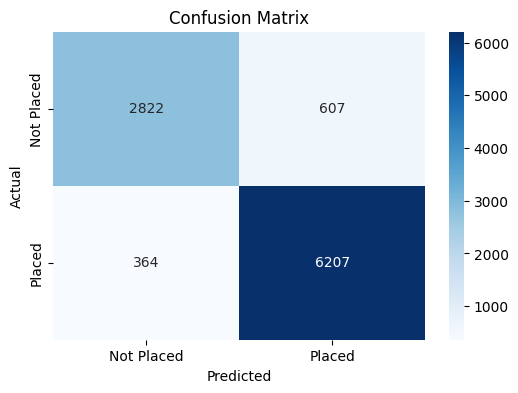

In [30]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [31]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.82      0.85      3429
           1       0.91      0.94      0.93      6571

    accuracy                           0.90     10000
   macro avg       0.90      0.88      0.89     10000
weighted avg       0.90      0.90      0.90     10000




AUC Score: 0.9661


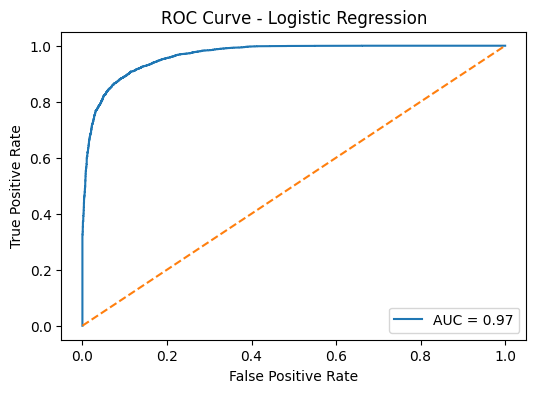

In [32]:
# Get probability of being placed

y_prob = model.predict_proba(
    X_test_scaled
)[:, 1]


# Calculate ROC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)


# Calculate AUC Score

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print(
    "\nAUC Score:",
    round(auc_score, 4)
)

# Plot ROC Curve

plt.figure(figsize=(6, 4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Logistic Regression"
)

plt.legend()

plt.show()